# Laboratory 9: A Deep Dive into Stable Diffusion

This laboratory covers:

* Differences between Stable Diffusion and the latent diffusion model
* Integrating Stable Diffusion in the `diffusers` library
* Various components of Stable Diffusion and their roles in text-to-image generation
* Interpolating text embeddings to generate a series of images that smoothly transition from one image to another

Stable Diffusion is based on the latent diffusion model (LDM) that we discussed in the previous laboratory. It's one of the state-of-the-art text-to-image models, along with OpenAI's DALL-E series and Google's Imagen. However, Stable Diffusion is the only one that is open-source and free for anyone to use.

Stable Diffusion is developed collaboratively by researchers from CompVis, Stability AI, and LAION. It's grounded in the innovative techniques described in the influential 2022 paper by Rombach et al.  Stable Diffusion has incorporated a host of improvements that enhance both the model's stability and performance. For instance, advanced training techniques and optimizations have been employed to produce higher-quality images with greater consistency. Moreover, while the original LDM was trained on the LAION-400M dataset (with 400 million image-text pairs), Stable Diffusion uses a subset of the even larger LAION-5B database, offering a richer and more diverse training foundation.

Beyond its technical advancements, Stable Diffusion has been designed with accessibility in mind. Its user-friendly applications and interfaces democratize the power of high-quality generative models, allowing users without deep technical expertise to explore and create state-of-the-art visual content from simple text prompts.

In this laboratory, we will learn how to harness the capabilities of Stable Diffusion using the Hugging Face `diffusers` library. We begin by demonstrating how to generate striking images with out-of-the-box tools, providing a hands-on introduction to the process. From there, we will peel back the layers of the model to reveal its main components. We will explore how the variational autoencoder (VAE), the denoising U-Net, and the CLIP text encoder work together to transform a text prompt into coherent, high-resolution images.

One of the most compelling aspects of this exploration is the technique of text embedding interpolation. By blending the embeddings of two different text prompts, we will observe how various mixtures of the conditioning information lead to a smooth visual transition between two images. For example, interpolating between the embeddings for “a lion” and “a tiger” will produce a series of images that gradually morph from a lion to a tiger. This step-by-step progression illustrates the power of conditional generation in diffusion models in general and underscores how text prompts steer the final output in particular.

By the end of this laboratory, we will be equipped not only to generate impressive images from textual descriptions using Stable Diffusion but also to understand the various processes that drive these results. This deeper insight into the architecture and function of Stable Diffusion will empower us to experiment further and potentially innovate in text-to-image generation.

# 1. Generating images with Stable Diffusion

In this section, we will learn how to create high-resolution images by using a version of Stable Diffusion that is integrated into the Hugging Face `diffusers` library. To install the library, run the following line of code.

In [ ]:
!pip install diffusers

In [ ]:
!pip install transformers==4.55.4

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 113.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 53.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 119.9 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.11.0
    Uninstalling huggingface_hub-1.11.0:
      Successfully uninstalled huggingface_hub-1.11.0
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


The `diffusers` library provides a standardized, user-friendly interface that abstracts
away much of the underlying complexity of the diffusion process. The integration
makes this state-of-the-art technology more approachable to the general public. The
`StableDiffusionPipeline`
package in the `diffusers` library allows us to use Stable Diffusion
as an off-the-shelf tool to generate extraordinary images in just a few lines of code.

Let's use the prompt "an astronaut in a spacesuit riding a unicorn" to generate an image:

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

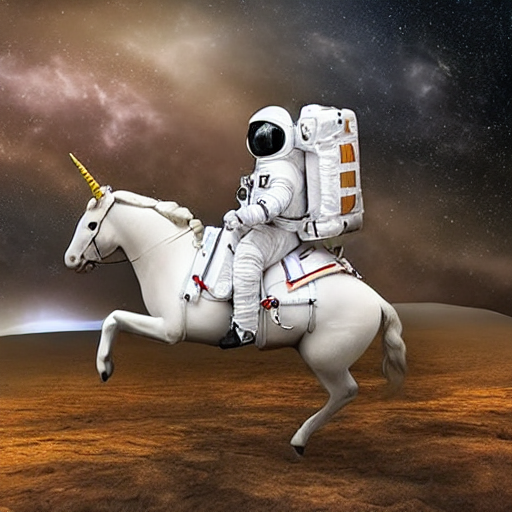

In [ ]:
#2min
import torch
from diffusers import StableDiffusionPipeline

torch.manual_seed(42)
prompt="an astronaut in a spacesuit riding a unicorn"
pipe = StableDiffusionPipeline.from_pretrained( #Uses the StableDiffusionPipeline package in the diffusers library
    "CompVis/stable-diffusion-v1-4", #Selects the version of the Stable Diffusion model
    variant="fp16", #Chooses the half-precision floating-point format
    torch_dtype=torch.float16).to("cuda")
image = pipe(prompt).images[0]
image

The `from_pretrained()` method in the `StableDiffusionPipeline` package loads a pretrained
version of the Stable Diffusion model. Here,
we will use the version `stable-diffusion-v1-4`. The first time we use it, Python downloads
the pretrained weights. Because the weights are large (more than $1$
GB), we will use this version for all examples in this laboratory. If we want to use a different version of
the pretrained model, we simply change the version name in the code cell.

The arguments `variant="fp16"` and `torch_dtype=torch.float16` mean that we load
a model checkpoint using the half-precision floating-number format. The default data
type in PyTorch tensors is `float32`, a $32$-bit floating-point number. A half-precision floating-point number, `float16`, provides less precise results than `float32` but also takes
less time to compute, thereby speeding up the image-generation process.

The generated image clearly shows an astronaut riding a unicorn on an alien planet.
This indicates that Stable Diffusion can convert various concepts (e.g., “astronaut,”
“spacesuit,” and “unicorn”) in natural language into visual concepts and generate a
coherent image.

We can generate multiple images at once. Here, we generate three images using three
different prompts:

  0%|          | 0/50 [00:00<?, ?it/s]

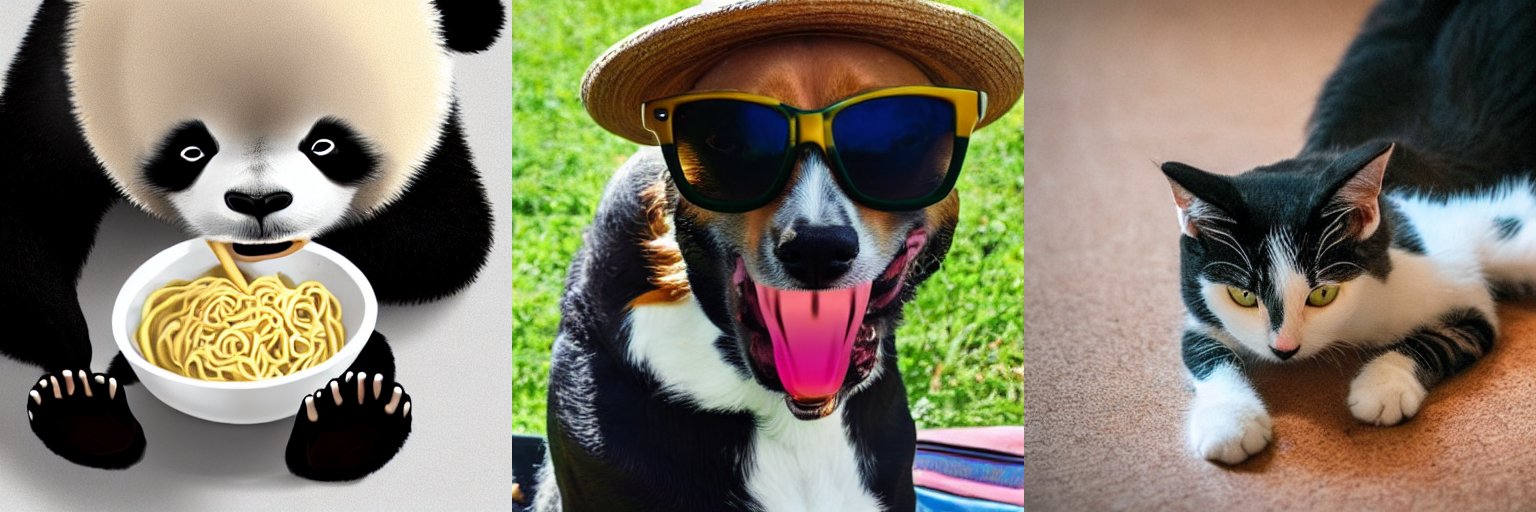

In [ ]:
from PIL import Image

torch.manual_seed(0)
prompts = ["a panda eating a bowl of noodles",
    "a dog with sunglasses and a straw hat",
    "a cat stretching on the floor"] #Provides a list of three different text prompts
images = pipe(prompts).images
grid = Image.new('RGB', size=(3*images[0].size[0],
                  images[0].size[1]))
for i, img in enumerate(images): #Places the three output images in a 1 × 3 grid
    grid.paste(img, box=(i*images[0].size[0], 0))
grid

We use three different prompts in a list. The generated images are displayed in a $1 \times 3$ grid.

So far, we have used the default values of image resolution ($512 \times 512$) and the classifier-free
guidance (CFG) parameter (set to `7.5`) in the `StableDiffusionPipeline` package.
However, we can change these parameter values, as in this example:

  0%|          | 0/50 [00:00<?, ?it/s]

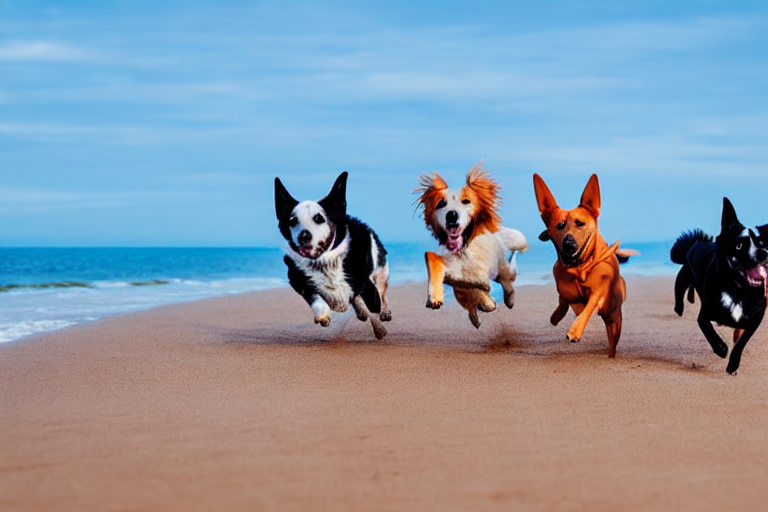

In [ ]:
torch.manual_seed(42)
prompt = "dogs running on a sandy beach under blue sky"
images = pipe(prompt,width=768,height=512, #Sets the image resolution to 768 × 512
             guidance_scale=12).images #Changes the CFG parameter to 12
images[0]

In this example, we have changed the image resolution to $768 \times 512$ and set the CFG
parameter, `guidance_scale`, to `12`.

The output shows four dogs running on a sandy beach under a blue sky. The generation
takes just a few seconds.

# 2. Creating text embeddings

Stable Diffusion consists of three main parts: a text encoder,
a U-Net, and a VAE decoder. The first step in text-to-image generation is to convert the
text prompts to text embeddings. These embeddings are used as the conditioning factors
when generating latent images.

In this section, we discuss how text embeddings are generated, using the two prompts,
“a lion” and “a tiger,” as our examples. To that end, we first create a `Config()` class to store
the hyperparameters used in the model. We also define the two example prompts:

In [ ]:
class Config:
    height = 512    #Height of the generated image
    width = 512    #Width of the generated image
    guidance_scale = 7.5    #CFG-guidance parameter
    num_inference_steps=50    #Number of inference steps
config=Config()

prompts1 = ["a lion"] #Prompt 1
prompts2 = ["a tiger"] #Prompt 2

The height and width of the generated images are $512$ pixels. We will use $50$ inference
steps. The CFG scale is set at `7.5`, which is the default value of the parameter in the
`StableDiffusionPipeline` package in the `diffusers` library. We import the pretrained
CLIP tokenizer and text encoder from the `transformers` library:

In [ ]:
from transformers import CLIPTextModel, CLIPTokenizer
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer = CLIPTokenizer.from_pretrained(
    "openai/clip-vit-large-patch14") #Imports the pretrained CLIP tokenizer
text_encoder = CLIPTextModel.from_pretrained(
    "openai/clip-vit-large-patch14").to(device) #Imports the pretrained CLIP text encoder

tokenizer_config.json:   0%|          | 0.00/905 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

Now we can tokenize the two text prompts and convert them into text embeddings:

In [ ]:
tokens1=tokenizer(prompts1,padding="max_length",
              max_length=tokenizer.model_max_length,
              truncation=True, return_tensors="pt")
tokens2=tokenizer(prompts2,padding="max_length",
              max_length=tokenizer.model_max_length,
              truncation=True, return_tensors="pt") #Converts the two prompts into sequences of indices
with torch.no_grad():
    text_embeddings1=text_encoder(
        tokens1.input_ids.to(device))[0]
    text_embeddings2=text_encoder(
        tokens2.input_ids.to(device))[0] #Generates two text embeddings
print("text embedding 1 shape:", text_embeddings1.shape)
print("text embedding 2 shape:", text_embeddings1.shape)

text embedding 1 shape: torch.Size([1, 77, 768])
text embedding 2 shape: torch.Size([1, 77, 768])


Both text embeddings have a shape of $(1, 77, 768)$: one prompt in each batch, with
$77$ tokens for each prompt, and each token represented by a $768$-value tensor. As we
explained in Laboratory 8, the CLIP text encoder is designed to accept inputs of a fixed
length ($77$ tokens). If a prompt is shorter than $77$ tokens, it gets padded.

We also create an unconditional text embedding for CFG:

In [ ]:
unconditional_prompt = [""] #The unconditional prompt is an empty string.
uncond_input = tokenizer(unconditional_prompt,
             padding="max_length",
             max_length=tokenizer.model_max_length,
             return_tensors="pt") #Tokenizes the unconditional prompt
with torch.no_grad():
    uncond_embeds=text_encoder(
        uncond_input.input_ids.to(device))[0] #Converts the unconditional prompt into a text embedding

The unconditional prompt is nothing more than an empty string that we tokenize and
convert into a text embedding. When we use it to guide image generation in the latent
space, the text embedding leads to unconditional image generation. We will concatenate
the unconditional text embedding and the prompt text embeddings to form the final
text embeddings. As we explained in Laboratory 5, the final output is a combination of
conditional generation and unconditional generation. The CFG parameter controls
how much the final output relies on conditional generation as opposed to unconditional
generation.

# 3. Image generation in the latent space


Stable Diffusion performs image generation in a lower-dimensional
latent space to dramatically reduce memory requirements and computation
time. In this section, we will walk through the practical steps of generating images in
the latent space using the K-LMS scheduler from the K-Diffusion models and explain
several subtleties that are important for high-quality results.

A crucial aspect of diffusion-based image generation is the choice of scheduler,
which controls how noise is removed from the latent image over a sequence of inference
steps. Different schedulers, such as Denoising Diffusion Implicit Model (DDIM)
and Linear Multi-Step (LMS; used here), implement different numerical solvers for the
reverse diffusion process.

Schedulers can significantly influence both the inference speed (how fast an image
is generated) and the visual fidelity (how realistic and detailed the output appears).
For instance, the DDIM scheduler is generally faster and allows for fewer steps but may
sometimes produce slightly lower-quality images compared to LMS. The LMS scheduler
often yields higher visual fidelity, especially when generating complex or high-resolution
images, though it may take a bit more time per image.

We will use the K-LMS scheduler, a type of sampling scheduler used in the context of
K-Diffusion models. The LMS methods are a class of numerical solvers for differential
equations, which are integral to diffusion models. They aim to estimate the value of the
solution at a new point by using a linear combination of previously computed points.
This makes LMS methods well-suited for modeling the iterative nature of diffusion
processes. In diffusion models, the goal is to learn a reverse diffusion process that starts
from pure noise and progressively denoises it to generate realistic samples. K-Diffusion
models incorporate a series of steps, each refining the generated sample further. The
K-LMS scheduler specifically focuses on efficiently handling these iterative steps. First,
we import the K-LMS scheduler and the pretrained conditional denoising U-Net from
the `diffusers` library:

In [ ]:
#4min
from diffusers import LMSDiscreteScheduler
from diffusers import UNet2DConditionModel

scheduler = LMSDiscreteScheduler(beta_start=0.00085,
                     beta_end=0.012,
                     beta_schedule="scaled_linear",
                     num_train_timesteps=1000) #Creates the K-LMS scheduler

unet = UNet2DConditionModel.from_pretrained(
    "CompVis/stable-diffusion-v1-4", subfolder="unet")
unet = unet.to(device) #Creates the pretrained denoising U-Net

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

We will start with pure noise tensors. These noise tensors have the same shape, $(4, 64, 64)$, as the final clean image in the latent space. We then denoise the image for $50$
inference steps. These steps are implemented in the `gen_latents()` function.

In [ ]:
from tqdm import tqdm

def gen_latents(text_embeddings, seed):
    torch.manual_seed(seed)
    scheduler.set_timesteps(config.num_inference_steps)
    latents = torch.randn((1, unet.config.in_channels, #The starting image consists of pure random noise.
           config.height // 8, config.width // 8)).to(device)
    latents = latents * scheduler.init_noise_sigma
    text_embeddings=torch.cat([uncond_embeds, text_embeddings])
    with torch.autocast(device):
        for i, t in tqdm(enumerate(scheduler.timesteps)): #Iteratively denoises the image for 50 inference steps
            latent_model_input = torch.cat([latents] * 2)
            sigma = scheduler.sigmas[i]
            latent_model_input = scheduler.scale_model_input(
                latent_model_input, t)
            with torch.no_grad():
                noise_pred = unet(latent_model_input, t,
                  encoder_hidden_states=text_embeddings).sample
            noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)
            noise_pred=noise_pred_uncond+config.guidance_scale*(
                noise_pred_text - noise_pred_uncond)
            latents = scheduler.step(noise_pred,
                                     t, latents).prev_sample
    return 1 / 0.18215 * latents #Divides the output by 0.18215 to undo a previous scaling during training

The `gen_latents()` function takes two arguments, `text_embeddings` and `seed`. The first
argument is the text embedding of the text prompt, while the `seed` argument ensures
that the output is reproducible.

We may be wondering why we scale the final output by $0.18215$ in the `gen_latents()`
function. In Stable Diffusion and other LDMs, the latent images are divided by a factor
of $0.18215$ to reverse a scaling applied during training. When these models are trained,
an input image is first encoded into a latent representation, and then this representation
is multiplied by $0.18215$ to normalize its range to ensure training stability and
convergence. When a new latent sample is generated, dividing by $0.18215$ undoes the
scaling, returning the data to the original image space.

The value $0.18215$ is not chosen at random. During VAE training,
researchers found that encoding real images into the latent space produced
latent vectors with a standard deviation of about $0.18215$, rather than $1$. By
dividing the latent vectors by $0.18215$, we normalize their standard deviation
to $1$. This normalization ensures that the decoder receives inputs consistent with what it was exposed to during training, which is crucial for producing
high-quality image reconstructions.

Now we can apply the `gen_latents()` function on the two text embeddings we generated
in the previous section to obtain two latent images for the text prompts “a lion”
and “a tiger”:

In [ ]:
latents1=gen_latents(text_embeddings1,seed=5)
latents2=gen_latents(text_embeddings2,seed=5)
print(f"latent image size is {latents1[0].shape}")

50it [00:07,  6.39it/s]
50it [00:07,  6.49it/s]

latent image size is torch.Size([4, 64, 64])


The two latent images have a shape of $(4, 64, 64)$. We will convert them into high-resolution
images in the next section.

# 4. Converting latent images to high-resolution ones


We will use the pretrained VAE to convert the low-resolution images in the latent space
to high-resolution ones as the final output of the Stable Diffusion model. In the following
code cell, we import the pretrained VAE from the `diffusers` library:

In [ ]:
from diffusers import AutoencoderKL

vae = AutoencoderKL.from_pretrained(
      "CompVis/stable-diffusion-v1-4",
      subfolder="vae").to(device)

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Now we can use the VAE decoder to convert latent images to high-resolution ones:

In [ ]:
with torch.no_grad():
    images1 = vae.decode(latents1).sample
    images2 = vae.decode(latents2).sample
print(f"final image size is {images2[0].shape}")

final image size is torch.Size([3, 512, 512])


After VAE decoding, each image has a shape of $3 \times 512 \times 512$.

We can plot the two latent images and the two final high-resolution images in a $1 \times 4$
grid:

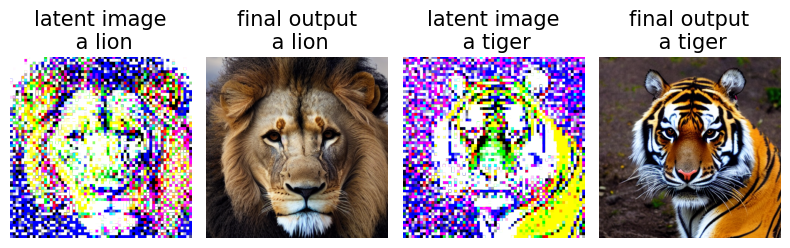

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def latent_to_display_image(latent, upsample_factor=8):
    """
    Processes a latent tensor for display:
    - Permutes to (H, W, C)
    - Clips to [-1, 1]
    - Upsamples by repeating pixels
    - Rescales from [-1, 1] to [0, 1]
    - Converts to numpy array
    """
    # Permute, clip to [-1,1], and detach
    image = latent[0].permute(1, 2, 0).detach().cpu()
    image = torch.clamp(image, -1, 1)
    # Upsample by repeating pixels
    image = image.repeat_interleave(upsample_factor,
        dim=0).repeat_interleave(upsample_factor, dim=1)
    # Rescale to [0,1]
    image = (image + 1) / 2
    return image.numpy() #Changes the latent image to a displayable format

def output_to_display_image(output):
    """
    Processes a final output image tensor for display:
    - Permutes to (H, W, C)
    - Rescales from [-1, 1] to [0, 1] if needed
    - Clips to [0, 1]
    - Converts to numpy array
    """
    image = output[0].permute(1, 2, 0).detach().cpu()
    image = (image + 1) / 2
    image = torch.clamp(image, 0, 1)
    return image.numpy() #Changes the final output image to a displayable format

# Prepare images for display
display_imgs = [
    latent_to_display_image(latents1),
    output_to_display_image(images1),
    latent_to_display_image(latents2),
    output_to_display_image(images2)
]

captions = [
    "latent image\n a lion",
    "final output\n a lion",
    "latent image\n a tiger",
    "final output\n a tiger" #Creates four captions
]

plt.figure(figsize=(8, 5), dpi=100)
for i in range(4): #Plots the four images in a 1 × 4 grid
    plt.subplot(1, 4, i + 1)
    plt.imshow(display_imgs[i])
    plt.title(captions[i], fontsize=15)
    plt.axis('off')
plt.tight_layout()
plt.show()



We define the `latent_to_display_image()` function to convert a latent image tensor
into a format suitable for visualization. This function performs several operations: it
rearranges the tensor from channels-first to channels-last order, clips the values to the range $[-1, 1]$, detaches the tensor from the computation graph, and moves it from the
GPU to the CPU for compatibility with visualization libraries. Additionally, it upsamples
the latent image so that all displayed images have the same height and width,
ensuring they align properly in the same row. The `output_to_display_image()` function
follows a similar process, but because the output image is already at the desired
resolution, it doesn't require upsampling.

We place the formatted latent images and final output images in the list `display_imgs`. We also create four captions, one for each image.

The first and the third images above are the latent images. Even though they
have low resolution, we can tell that they are a lion and a tiger, respectively. This indicates
that the latent images have captured the essence of the two text prompts. The
VAE decoder then converts these two latent images into high-resolution ones, as shown
in the second and fourth subplot in the figure above.

We can interpolate the two text embeddings, `text_embeddings1` and `text_embeddings2`,
to create new embeddings with various weights:

In [ ]:
images=[]
for weight in [0.9, 0.7, 0.5, 0.3, 0.1]: #Chooses five different values of weights
    text_embeddings = weight * text_embeddings1 +\
        (1-weight) * text_embeddings2 #Creates an interpolated text embedding based on the weight
    latents=gen_latents(text_embeddings,seed=5) #Generates a latent image based on the text embedding
    with torch.no_grad():
        images.append(vae.decode(latents).sample) #Converts the latent image into a high-resolution image

50it [00:07,  6.59it/s]
50it [00:07,  6.51it/s]
50it [00:07,  6.35it/s]
50it [00:08,  6.16it/s]
50it [00:08,  5.77it/s]


The variable `weight` is the weight we place on the text embedding for the “a lion”
prompt. It takes five values, $0.9, 0.7, 0.5, 0.3,$ and $0.1$. The complementary weight is
placed on the text embedding for the “a tiger” prompt. The interpolated text embedding
is fed to the `gen_latents()` function to generate a latent image, which is then converted
into a high-resolution image using the VAE decoder. The five high-resolution
images are placed in a list `images`. We plot the five interpolated images in a $1 \times 5$ grid:

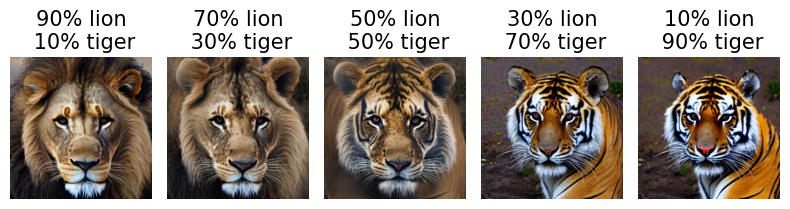

In [ ]:
plt.figure(figsize=(8,5),dpi=100)
for i in range(5): #Plots the five images in a 1 × 5 grid
    plt.subplot(1,5,i+1)
    img=torch.clip(images[i][0].detach().cpu(
        ).permute(1,2,0)/2+0.5,0,1)
    plt.imshow(img)
    plt.title(f"{90-20*i}% lion\n {10+20*i}% tiger",
              fontsize=15) #Labels the images
    plt.axis('off')
plt.tight_layout()
plt.show()

The first image shows the final output when we use $90\%$ of the text embedding for “a
lion” and $10\%$ of the text embedding for “a tiger” to create the interpolated embedding.
As we move to the right, the weight on the text embedding for “a lion” decreases and that on the text embedding for “a tiger” increases. As a result, when you move
from left to right, the images show more characteristics of a tiger and fewer characteristics
of a lion.

#Exercises

1. Change the text prompt to “a futuristic city at sunrise” in the image generation with the `diffusers` library code. Rerun the code to see the generated image.

2. Define `prompt3` and `prompt4` as “a leopard” and “a lioness”, respectively. Then tokenize
the two prompts, and convert them to text embeddings, `text_embedding3` and
`text_embedding4`.

3. Apply the `gen_latents()` function on the two text embeddings `text_embedding3` and
`text_embedding4`, which were generated earlier. Set the seed value to `8`. Name the
latent images `latents3` and `latents4`.

4. Convert the two latent images, `latents3` and `latents4`, into high-resolution images.
Name them `images3` and `images4`, respectively.

5. Plot the two latent images, `latents3` and `latents4`, and the two outputs, `images3`
and `images4`, in a $1 \times 4$ grid. Label the four images accordingly.

6. Let the variable `weight` take five values, `0.9`, `0.7`, `0.5`, `0.3`, and `0.1`. Create five interpolated
text embeddings of `text_embeddings3` and `text_embeddings4` based on
these weights. Feed the interpolated text embeddings to the `gen_latents()` function
to generate five latent images. Convert the five latent images to high-resolution ones
using the VAE decoder. Plot the five high-resolution images in a $1 \times 5$ grid, and label them accordingly.